# first method

In [48]:
import pandas as pd

# خواندن فایل
file = "ThermoML_properties.xlsx"

df = pd.read_excel(file, sheet_name=0)

print("="*60)
print("Sheet Name:")
print(pd.ExcelFile(file).sheet_names[0])

print("="*60)
print("Shape:")
print(df.shape)

print("="*60)
print("Columns:")
print(df.columns.tolist())

print("="*60)
print("Data Types:")
print(df.dtypes)

print("="*60)
print("First 10 Rows:")
print(df.head(10))

print("="*60)
print("Missing Values:")
print(df.isnull().sum())

print("="*60)
print("Statistics:")
print(df.describe(include='all'))

print("="*60)
print("Unique Compounds:")
print(df["Compound"].nunique())

print("="*60)
print("Example Compound Names:")
print(df["Compound"].drop_duplicates().head(20))

Sheet Name:
Thermal conductivity, WmK
Shape:
(1239, 7)
Columns:
['Compound', 'Temperature, K', 'Pressure, kPa', 'Mole fraction', 'Molality, mol/kg', 'Mass fraction', 'Thermal conductivity, W/m/K']
Data Types:
Compound                        object
Temperature, K                 float64
Pressure, kPa                  float64
Mole fraction                  float64
Molality, mol/kg               float64
Mass fraction                  float64
Thermal conductivity, W/m/K    float64
dtype: object
First 10 Rows:
                         Compound  Temperature, K  Pressure, kPa  \
0  methane,carbane,carbon dioxide         298.893         6100.0   
1  methane,carbane,carbon dioxide         299.016         5760.0   
2  methane,carbane,carbon dioxide         299.192         5400.0   
3  methane,carbane,carbon dioxide         299.309         5035.0   
4  methane,carbane,carbon dioxide         299.498         4555.0   
5  methane,carbane,carbon dioxide         299.603         3980.0   
6  methane,ca

In [49]:
import pandas as pd

# خواندن فایل
df = pd.read_excel("ThermoML_properties.xlsx", sheet_name=0)

print("قبل از حذف:", df.shape)

# حذف ردیف‌هایی که دما ندارند
df = df.dropna(subset=["Temperature, K"])

print("بعد از حذف:", df.shape)

# ذخیره فایل جدید
df.to_excel("ThermalConductivity_Clean.xlsx", index=False)

print("فایل ذخیره شد.")

قبل از حذف: (1239, 7)
بعد از حذف: (1227, 7)
فایل ذخیره شد.


In [50]:
def experiment_type(row):

    conditions = ["T"]

    if pd.notna(row["Pressure, kPa"]):
        conditions.append("P")

    if pd.notna(row["Mole fraction"]):
        conditions.append("Mole")

    if pd.notna(row["Molality, mol/kg"]):
        conditions.append("Molality")

    if pd.notna(row["Mass fraction"]):
        conditions.append("Mass")

    return " & ".join(conditions)


df["ExperimentType"] = df.apply(experiment_type, axis=1)


summary = (
    df.groupby(["Compound", "ExperimentType"], sort=False)
      .size()
      .reset_index(name="Number_of_rows")
)




summary.to_excel(
    "Correct_Compound_summary.xlsx",
    index=False
)


summary

,Compound,ExperimentType,Number_of_rows
0,"methane,carbane,carbon dioxide",T & P,77
1,"methane,carbane,carbon dioxide",T & P & Mole,180
2,"potassium sulfate,dipotassium sulfate,sulfuric...",T & P,59
3,"potassium sulfate,dipotassium sulfate,sulfuric...",T & P & Molality,262
4,"1,2-ethanediol,1,2-dihydroxyethane,ethane-1,2-...",T,20
5,"mercury,mercury element,quecksilber,quicksilve...",T,34
6,"argon,R-740",T & P,53
7,"indium,tin",T,18
8,lead,T,3
9,1-butyl-3-methylimidazolium hexafluorophosphat...,T & P,63


In [51]:
test = df[df["Compound"].str.contains("methane", case=False, na=False)]

test[[
    "Compound",
    "Temperature, K",
    "Pressure, kPa",
    "Mole fraction"
]].head(20)

,Compound,"Temperature, K","Pressure, kPa",Mole fraction
0,"methane,carbane,carbon dioxide",298.893,6100.0,NaN
1,"methane,carbane,carbon dioxide",299.016,5760.0,NaN
2,"methane,carbane,carbon dioxide",299.192,5400.0,NaN
3,"methane,carbane,carbon dioxide",299.309,5035.0,NaN
4,"methane,carbane,carbon dioxide",299.498,4555.0,NaN
5,"methane,carbane,carbon dioxide",299.603,3980.0,NaN
6,"methane,carbane,carbon dioxide",299.728,3285.0,NaN
7,"methane,carbane,carbon dioxide",299.847,2555.0,NaN
8,"methane,carbane,carbon dioxide",300.064,1702.0,NaN
9,"methane,carbane,carbon dioxide",300.372,714.0,NaN


In [52]:
[c for c in df.columns if "fraction" in c.lower() or "mole" in c.lower() or "compound" in c.lower()]

['Compound', 'Mole fraction', 'Mass fraction']

In [55]:
df[df["Compound"].str.contains("methane", case=False, na=False)].tail(180+79)

,Compound,"Temperature, K","Pressure, kPa",Mole fraction,"Molality, mol/kg",Mass fraction,"Thermal conductivity, W/m/K",ExperimentType
0,"methane,carbane,carbon dioxide",298.893,6100.0,NaN,NaN,NaN,0.03312,T & P
1,"methane,carbane,carbon dioxide",299.016,5760.0,NaN,NaN,NaN,0.02896,T & P
2,"methane,carbane,carbon dioxide",299.192,5400.0,NaN,NaN,NaN,0.02633,T & P
3,"methane,carbane,carbon dioxide",299.309,5035.0,NaN,NaN,NaN,0.02441,T & P
4,"methane,carbane,carbon dioxide",299.498,4555.0,NaN,NaN,NaN,0.02268,T & P
...,...,...,...,...,...,...,...,...
252,"methane,carbane,carbon dioxide",425.000,4800.0,0.7496,NaN,NaN,0.04980,T & P & Mole
253,"methane,carbane,carbon dioxide",425.000,5520.0,0.7496,NaN,NaN,0.05001,T & P & Mole
254,"methane,carbane,carbon dioxide",425.000,7670.0,0.7496,NaN,NaN,0.05089,T & P & Mole
255,"methane,carbane,carbon dioxide",425.000,9820.0,0.7496,NaN,NaN,0.05188,T & P & Mole


In [58]:
target = "methane,carbane,carbon dioxide"

data = df[df["Compound"] == target]

print("Total:", len(data))


co2_pure = data[data["Mole fraction"].isna()]
mixture = data[data["Mole fraction"].notna()]


print("CO2 pure:", len(co2_pure))
print("Mixture:", len(mixture))

Total: 257
CO2 pure: 77
Mixture: 180


In [59]:
import pandas as pd

# داده اصلی مقاله
target = "methane,carbane,carbon dioxide"

data = df[df["Compound"] == target].copy()


# دسته‌بندی
data["Dataset_Type"] = data["Mole fraction"].apply(
    lambda x: "CO2 Pure" if pd.isna(x) else "CH4-CO2 Mixture"
)


# خلاصه
summary = (
    data.groupby("Dataset_Type")
    .agg(
        Number_of_Experiments=("Thermal conductivity, W/m/K", "count"),
        Temperature_min=("Temperature, K", "min"),
        Temperature_max=("Temperature, K", "max"),
        Pressure_min=("Pressure, kPa", "min"),
        Pressure_max=("Pressure, kPa", "max"),
        Mole_fraction_values=("Mole fraction", lambda x: ", ".join(
            map(str, sorted(x.dropna().unique()))
        ))
    )
    .reset_index()
)


print(summary)


# ذخیره اکسل
summary.to_excel(
    "CO2_CH4_summary.xlsx",
    index=False
)

      Dataset_Type  Number_of_Experiments  Temperature_min  Temperature_max  \
0  CH4-CO2 Mixture                    180          300.000          425.000   
1         CO2 Pure                     77          298.893          428.047   

   Pressure_min  Pressure_max    Mole_fraction_values  
0         724.0       11970.0  0.2493, 0.4994, 0.7496  
1         497.0       15010.0                          


In [60]:
temperature_summary = (
    data.groupby(["Dataset_Type", "Temperature, K"])
    .size()
    .reset_index(name="Number_of_points")
)

temperature_summary.to_excel(
    "CO2_CH4_temperature_summary.xlsx",
    index=False
)

temperature_summary

,Dataset_Type,"Temperature, K",Number_of_points
0,CH4-CO2 Mixture,300.000,30
1,CH4-CO2 Mixture,325.000,30
2,CH4-CO2 Mixture,350.000,30
3,CH4-CO2 Mixture,375.000,30
4,CH4-CO2 Mixture,400.000,30
...,...,...,...
78,CO2 Pure,427.513,1
79,CO2 Pure,427.665,1
80,CO2 Pure,427.700,1
81,CO2 Pure,427.952,1


In [61]:
mixture = data[data["Mole fraction"].notna()]

print(
    sorted(mixture["Mole fraction"].unique())
)

[np.float64(0.2493), np.float64(0.4994), np.float64(0.7496)]


CO2 points: 77

CO2 Pure
Best Validation Loss: 0.0016097401967272162
Test MAE : 0.0006061759791274858
Test RMSE: 0.00111585037267476
Test R2  : 0.9650133076494296


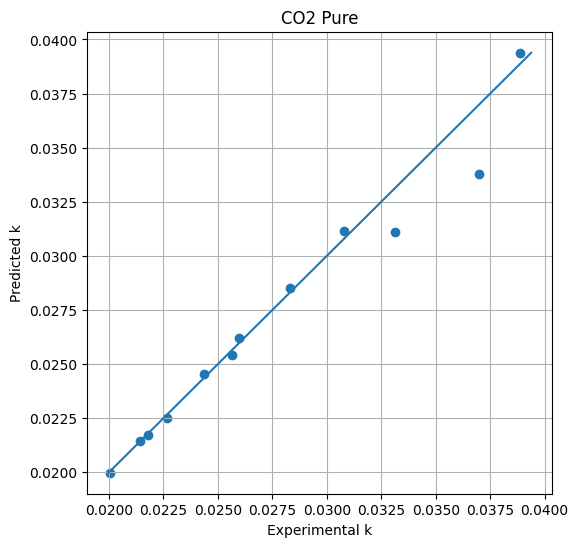

Mixture points: 180

CH4-CO2 Mixture
Best Validation Loss: 0.0008495303336530924
Test MAE : 0.0002016814068732438
Test RMSE: 0.0003313373463380553
Test R2  : 0.9974274536917161


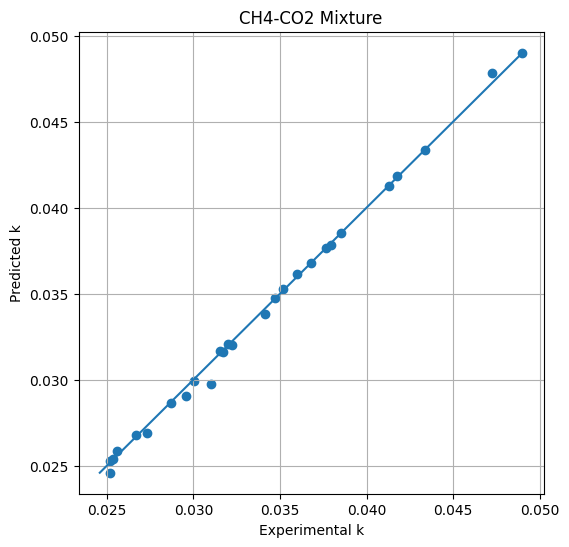

In [66]:
import pandas as pd
import numpy as np
import torch
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt


# =====================================================
# خواندن داده
# =====================================================

df = pd.read_excel(
    "ThermoML_properties.xlsx",
    sheet_name=0
)


target = "methane,carbane,carbon dioxide"

data = df[df["Compound"] == target].copy()



# =====================================================
# تابع ساخت و آموزش شبکه
# =====================================================

def train_network(X, y, input_size, name):


    # -------------------------
    # Train/Test split
    # -------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=42
    )


    # -------------------------
    # Validation split
    # -------------------------

    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.176,
        random_state=42
    )


    # چرا 0.176؟
    # چون 15 درصد کل داده validation می‌شود


    # -------------------------
    # Scaling
    # -------------------------

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()


    X_train = scaler_X.fit_transform(X_train)

    X_val = scaler_X.transform(X_val)

    X_test = scaler_X.transform(X_test)



    y_train = scaler_y.fit_transform(y_train)

    y_val = scaler_y.transform(y_val)

    y_test = scaler_y.transform(y_test)



    # تبدیل به Tensor

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    )


    X_val = torch.tensor(
        X_val,
        dtype=torch.float32
    )

    y_val = torch.tensor(
        y_val,
        dtype=torch.float32
    )


    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_test_tensor = torch.tensor(
        y_test,
        dtype=torch.float32
    )


    # -------------------------
    # Neural Network
    # -------------------------

    model = nn.Sequential(

        nn.Linear(input_size,10),

        nn.ReLU(),

        nn.Linear(10,10),

        nn.ReLU(),

        nn.Linear(10,1)

    )


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )


    loss_fn = nn.MSELoss()



    # -------------------------
    # Training
    # -------------------------

    best_val_loss = np.inf


    for epoch in range(2000):

        model.train()


        pred = model(X_train)


        loss = loss_fn(
            pred,
            y_train
        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()



        # validation

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = loss_fn(
                val_pred,
                y_val
            )


        if val_loss.item() < best_val_loss:

            best_val_loss = val_loss.item()


    print("\n====================")
    print(name)

    print("Best Validation Loss:",
          best_val_loss)



    # =================================================
    # Test واقعی
    # =================================================

    model.eval()


    with torch.no_grad():

        y_pred = model(X_test).numpy()



    y_true = scaler_y.inverse_transform(
        y_test
    )


    y_pred = scaler_y.inverse_transform(
        y_pred
    )



    MAE = mean_absolute_error(
        y_true,
        y_pred
    )


    RMSE = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    R2 = r2_score(
        y_true,
        y_pred
    )


    print("Test MAE :", MAE)

    print("Test RMSE:", RMSE)

    print("Test R2  :", R2)



    # -------------------------
    # نمودار
    # -------------------------

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_true,
        y_pred
    )


    mn = min(
        y_true.min(),
        y_pred.min()
    )

    mx = max(
        y_true.max(),
        y_pred.max()
    )


    plt.plot(
        [mn,mx],
        [mn,mx]
    )


    plt.xlabel(
        "Experimental k"
    )

    plt.ylabel(
        "Predicted k"
    )


    plt.title(name)

    plt.grid()

    plt.show()



    return model





# =====================================================
# مدل 1 : CO2 خالص
# =====================================================

co2 = data[
    data["Mole fraction"].isna()
]


print("CO2 points:",
      len(co2))


X_CO2 = co2[
    [
        "Temperature, K",
        "Pressure, kPa"
    ]
].values


y_CO2 = co2[
    [
        "Thermal conductivity, W/m/K"
    ]
].values



model_CO2 = train_network(
    X_CO2,
    y_CO2,
    2,
    "CO2 Pure"
)





# =====================================================
# مدل 2 : مخلوط
# =====================================================


mix = data[
    data["Mole fraction"].notna()
]


print("Mixture points:",
      len(mix))


X_mix = mix[
    [
        "Temperature, K",
        "Pressure, kPa",
        "Mole fraction"
    ]
].values


y_mix = mix[
    [
        "Thermal conductivity, W/m/K"
    ]
].values



model_mix = train_network(
    X_mix,
    y_mix,
    3,
    "CH4-CO2 Mixture"
)

# new method

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
df = pd.read_excel(
    "ThermoML_properties.xlsx",
    sheet_name=0
)


target = "methane,carbane,carbon dioxide"

data = df[df["Compound"] == target].copy()

In [69]:
def run_models(data, features, title):


    X = data[features]

    y = data[
        "Thermal conductivity, W/m/K"
    ]


    print("\n======================")
    print(title)

    print("Total points:", len(data))


    # -----------------------------
    # جدا کردن Test واقعی
    # -----------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=42
    )


    print("Train:",len(X_train))
    print("Test :",len(X_test))


    # -----------------------------
    # Scaling برای شبکه عصبی
    # -----------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )



    models = {

        "Linear Regression":
        LinearRegression(),


        "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),


        "XGBoost":
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42
        ),


        "Neural Network":
        MLPRegressor(
            hidden_layer_sizes=(20,10),
            max_iter=3000,
            random_state=42
        )

    }



    results = []



    for name, model in models.items():


        print("\nTraining:", name)



        if name == "Neural Network":

            model.fit(
                X_train_scaled,
                y_train
            )


            pred = model.predict(
                X_test_scaled
            )


        else:

            model.fit(
                X_train,
                y_train
            )


            pred = model.predict(
                X_test
            )



        MAE = mean_absolute_error(
            y_test,
            pred
        )


        RMSE = np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )


        R2 = r2_score(
            y_test,
            pred
        )



        results.append(
            [
                name,
                MAE,
                RMSE,
                R2
            ]
        )


        # نمودار

        plt.figure(figsize=(5,5))


        plt.scatter(
            y_test,
            pred
        )


        mn=min(
            y_test.min(),
            pred.min()
        )


        mx=max(
            y_test.max(),
            pred.max()
        )


        plt.plot(
            [mn,mx],
            [mn,mx]
        )


        plt.xlabel(
            "Experimental k"
        )

        plt.ylabel(
            "Predicted k"
        )


        plt.title(
            title+" - "+name
        )


        plt.grid()

        plt.show()



    result_df = pd.DataFrame(
        results,
        columns=[
            "Model",
            "MAE",
            "RMSE",
            "R2"
        ]
    )


    return result_df


CO2 Pure
Total points: 77
Train: 65
Test : 12

Training: Linear Regression


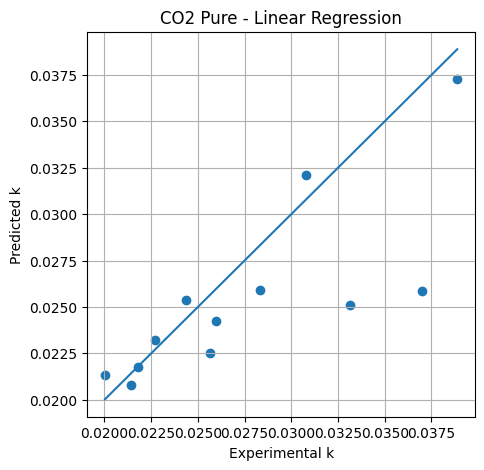


Training: Random Forest


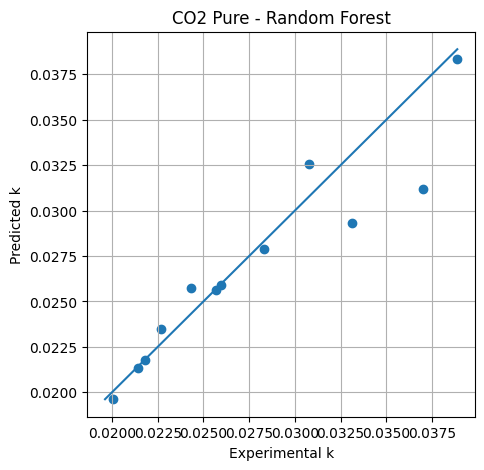


Training: XGBoost


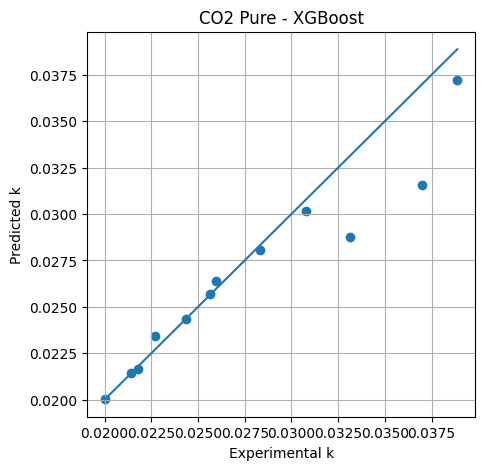


Training: Neural Network


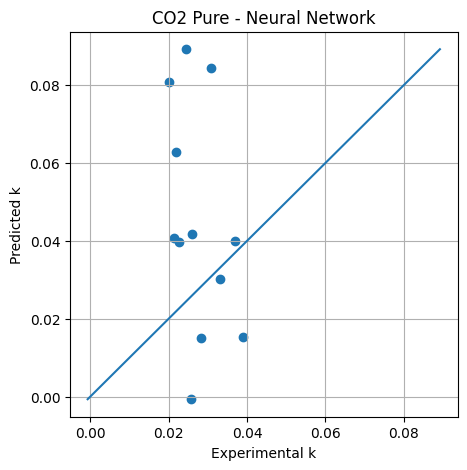

,Model,MAE,RMSE,R2
0,Linear Regression,0.002745,0.004234,0.496302
1,Random Forest,0.001263,0.002136,0.871757
2,XGBoost,0.001147,0.002091,0.877098
3,Neural Network,0.028463,0.035139,-33.694926


In [70]:
co2 = data[
    data["Mole fraction"].isna()
]


result_CO2 = run_models(
    co2,
    [
        "Temperature, K",
        "Pressure, kPa"
    ],
    "CO2 Pure"
)


result_CO2


CH4-CO2 Mixture
Total points: 180
Train: 153
Test : 27

Training: Linear Regression


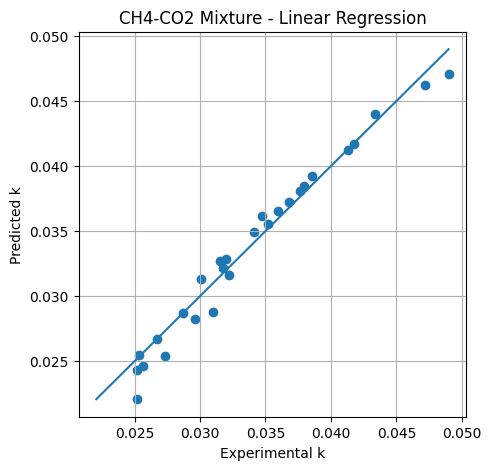


Training: Random Forest


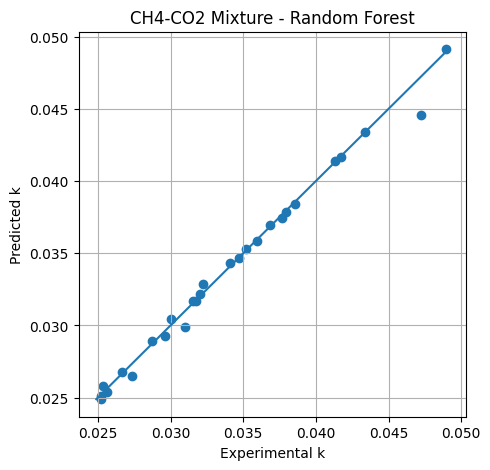


Training: XGBoost


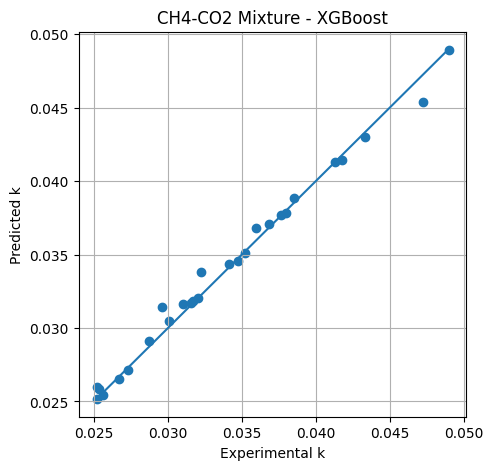


Training: Neural Network


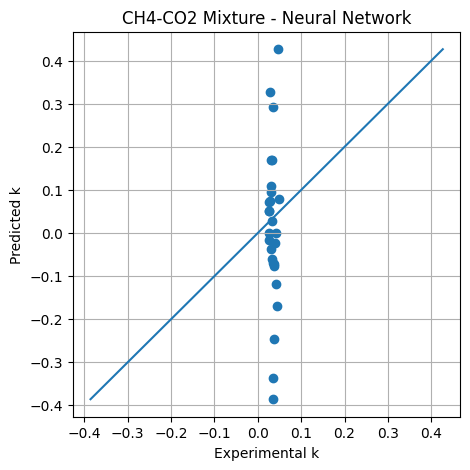

,Model,MAE,RMSE,R2
0,Linear Regression,0.000880,0.001144,0.969330
1,Random Forest,0.000344,0.000625,0.990859
2,XGBoost,0.000437,0.000675,0.989317
3,Neural Network,0.134931,0.180475,-762.234622


In [71]:
mixture = data[
    data["Mole fraction"].notna()
]


result_mix = run_models(
    mixture,
    [
        "Temperature, K",
        "Pressure, kPa",
        "Mole fraction"
    ],
    "CH4-CO2 Mixture"
)


result_mix